In [11]:
import sys
print(sys.executable)


c:\Btech\SEM4\FakeJobDeploy\job\Scripts\python.exe


An Explainable Machine Learning Framework for Fake Job Posting Detection Using Textual and Metadata Features

In [12]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, StackingClassifier

from scipy.sparse import hstack, csr_matrix
import joblib

import spacy
from spellchecker import SpellChecker

import xgboost as xgb

import lightgbm as lgb

import shap

import matplotlib.pyplot as plt



c:\Btech\SEM4\FakeJobDeploy\job\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
# Load NLP resources
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])
spell = SpellChecker()

ARTIFACTS = Path("artifacts")
ARTIFACTS.mkdir(exist_ok=True)


In [14]:
df = pd.read_csv(r"C:\Btech\SEM4\FakeJobDeploy\fake_job_postings.csv")
print(df.shape)
df.head()


(17880, 18)


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [15]:
total = len(df)
real = (df["fraudulent"] == 0).sum()
fraud = (df["fraudulent"] == 1).sum()

print(f"Total job postings: {total}")
print(f"Real jobs (0): {real}")
print(f"Fraudulent jobs (1): {fraud}")
print(f"Fraud percentage: {fraud/total*100:.2f}%")


Total job postings: 17880
Real jobs (0): 17014
Fraudulent jobs (1): 866
Fraud percentage: 4.84%


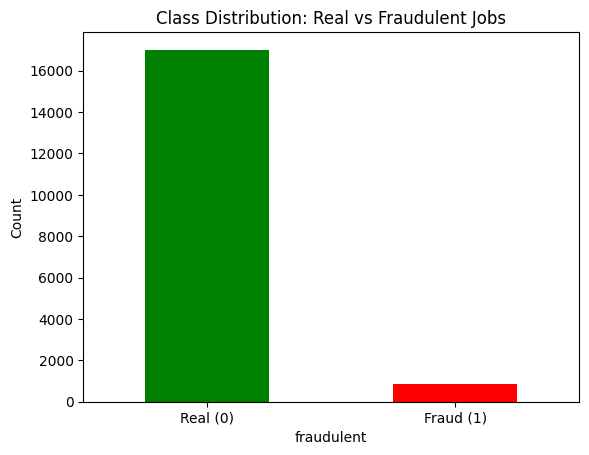

In [16]:
df["fraudulent"].value_counts().plot(
    kind="bar",
    color=["green", "red"],
    title="Class Distribution: Real vs Fraudulent Jobs"
)
plt.xticks([0, 1], ["Real (0)", "Fraud (1)"], rotation=0)
plt.ylabel("Count")
plt.show()

In [17]:
TEXT_COLS = ["title","company_profile","description","requirements","benefits"]

df["text"] = df[TEXT_COLS].fillna("").agg(" ".join, axis=1)
df = df[df["text"].str.strip().str.len() > 0]

df = df.reset_index(drop=True)


In [18]:
STOPWORDS = nlp.Defaults.stop_words

def clean_text_basic(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    doc = nlp(text)
    tokens = [
        token.lemma_
        for token in doc
        if token.lemma_ not in STOPWORDS and len(token.lemma_) > 2
    ]
    return " ".join(tokens)


In [19]:
#This code converts messy real-world job text into a linguistically normalized form so TF-IDF can learn meaningful fraud patterns instead of noise.
df["clean_text"] = df["text"].apply(clean_text_basic)

In [20]:
#there are the suspesious keywords, genaraly appears in fake job posting decription
SUSPICIOUS_KEYWORDS = [
    # money / income promises
    "earn", "earn money", "easy money", "quick money",
    "get paid", "paid daily", "paid weekly",
    "financial freedom", "extra income", "guaranteed income",

    # work from home + urgency
    "work from home", "remote work", "home based",
    "urgent hiring", "apply immediately", "immediate joining",

    # low barrier promises
    "no experience", "no interview", "no skills required",
    "anyone can apply", "freshers welcome", "students welcome",

    # scam payment channels
    "western union", "moneygram", "wire transfer",
    "bitcoin", "crypto", "wallet", "upi transfer", "gift card",

    # manipulation / persuasion
    "congratulations", "selected",
    "limited offer", "act now", "risk free", "100% genuine"
]

def suspicious_keyword_score(text):
    t = text.lower()
    hits = 0
    for kw in SUSPICIOUS_KEYWORDS:
        if kw in t:
            hits += 1
    return hits



In [21]:
#grammer eror ratio
def grammar_error_ratio(text):
    tokens = re.findall(r"[a-z']+", text.lower())
    if len(tokens) == 0:
        return 0.0
    miss = sum(1 for t in tokens if t not in spell)
    return miss / len(tokens)


In [22]:
#creating meta fetures 

df["text_length"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()
df["clean_text_length"] = df["clean_text"].str.len()

df["suspicious_keyword_count"] = df["text"].apply(suspicious_keyword_score)
df["has_suspicious_keyword"] = (df["suspicious_keyword_count"] > 0).astype(int)

df["grammar_error_ratio"] = df["text"].apply(grammar_error_ratio)

df["has_salary"] = df["salary_range"].notna().astype(int)
df["salary_range_length"] = 0
df["salary_anomaly"] = 0


In [23]:
#select meta columns
meta_cols = [
    "text_length","word_count","clean_text_length",
    "suspicious_keyword_count","has_suspicious_keyword",
    "grammar_error_ratio",
    "has_salary","salary_range_length","salary_anomaly",
    "telecommuting","has_company_logo","has_questions"
]

joblib.dump(meta_cols, ARTIFACTS/"meta_cols.joblib")


['artifacts\\meta_cols.joblib']

In [24]:
#Train/Test Split (Stratified)
X = df
y = df["fraudulent"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(Counter(y_train), Counter(y_test))


Counter({0: 13611, 1: 693}) Counter({0: 3403, 1: 173})


In [25]:
#TF-IDF (Train Only)
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2
)

Xtrain_text = tfidf.fit_transform(X_train["clean_text"])
Xtest_text  = tfidf.transform(X_test["clean_text"])

joblib.dump(tfidf, ARTIFACTS/"final_tfidf.joblib")


['artifacts\\final_tfidf.joblib']

In [26]:
#encoding meta features
X_train_meta = X_train[meta_cols].fillna(0).astype(float)
X_test_meta  = X_test[meta_cols].fillna(0).astype(float)

X_train_meta_sp = csr_matrix(X_train_meta.values)
X_test_meta_sp  = csr_matrix(X_test_meta.values)


In [27]:
#combining TFIDF + META
X_train_final = hstack([Xtrain_text, X_train_meta_sp]).tocsr()
X_test_final  = hstack([Xtest_text, X_test_meta_sp]).tocsr()

print(X_train_final.shape, X_test_final.shape)

joblib.dump((X_train_final, X_test_final), ARTIFACTS/"X_all_final.joblib")


(14304, 5012) (3576, 5012)


['artifacts\\X_all_final.joblib']

In [28]:
#Imbalance Handling
neg, pos = np.bincount(y_train)
class_weights = {0: pos/(pos+neg), 1: neg/(pos+neg)}
scale_pos_weight = neg / pos

print(class_weights, scale_pos_weight)


{0: np.float64(0.04844798657718121), 1: np.float64(0.9515520134228188)} 19.64069264069264


model training starts

In [ ]:
from sklearn.utils import resample

# Combine X_train and y_train indices
Xy_train_idx = np.arange(len(y_train))

# Separate indices
idx_real = Xy_train_idx[y_train.values == 0]
idx_fraud = Xy_train_idx[y_train.values == 1]

# Undersample real class
idx_real_under = resample(
    idx_real,
    replace=False,
    n_samples=len(idx_fraud) * 3,  # keep ~3x real
    random_state=42
)

idx_under = np.concatenate([idx_real_under, idx_fraud])

X_train_under = X_train_final[idx_under]
y_train_under = y_train.iloc[idx_under]

print("Undersampled distribution:", Counter(y_train_under))
joblib.dump((X_train_under, y_train_under), ARTIFACTS/"train_under.joblib")


Undersampled distribution: Counter({0: 2079, 1: 693})


['artifacts\\train_under.joblib']

# Random forest

In [30]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_under, y_train_under)
joblib.dump(rf, ARTIFACTS/"model_rf_under.joblib")


['artifacts\\model_rf_under.joblib']

In [31]:
rf_pred = rf.predict(X_test_final)
rf_proba = rf.predict_proba(X_test_final)[:,1]

print("Random Forest Report")
print(classification_report(y_test, rf_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_proba))


Random Forest Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3403
           1       0.82      0.73      0.77       173

    accuracy                           0.98      3576
   macro avg       0.90      0.86      0.88      3576
weighted avg       0.98      0.98      0.98      3576

ROC AUC: 0.9865767879073037


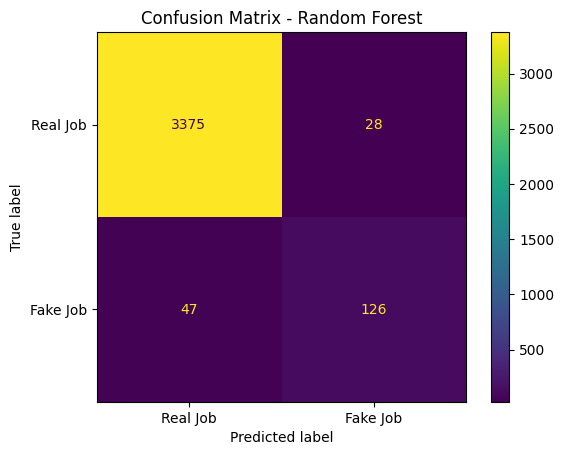

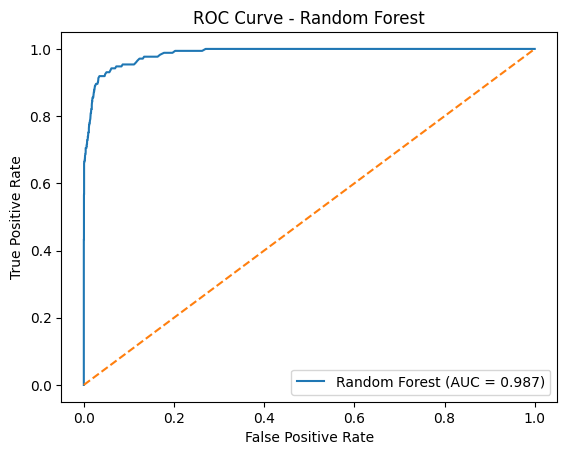

In [32]:
cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Real Job", "Fake Job"]
)

disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, rf_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend(loc="lower right")
plt.show()

# SVM

In [33]:
svc = LinearSVC(class_weight="balanced", max_iter=5000)
svc_cal = CalibratedClassifierCV(svc)

svc_cal.fit(X_train_final, y_train)
joblib.dump(svc_cal, ARTIFACTS/"model_svc_calibrated_full.joblib")


['artifacts\\model_svc_calibrated_full.joblib']

In [34]:
svm_pred = svc_cal.predict(X_test_final)
svm_proba = svc_cal.predict_proba(X_test_final)[:,1]

print("SVM Report")
print(classification_report(y_test, svm_pred))
print("ROC AUC:", roc_auc_score(y_test, svm_proba))


SVM Report
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3403
           1       0.91      0.76      0.83       173

    accuracy                           0.98      3576
   macro avg       0.95      0.88      0.91      3576
weighted avg       0.98      0.98      0.98      3576

ROC AUC: 0.9872434896784373


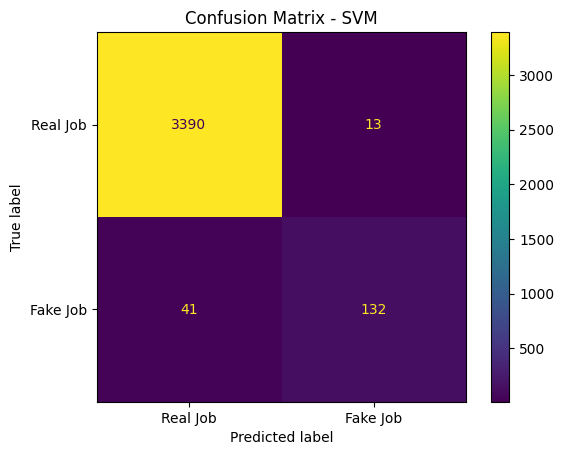

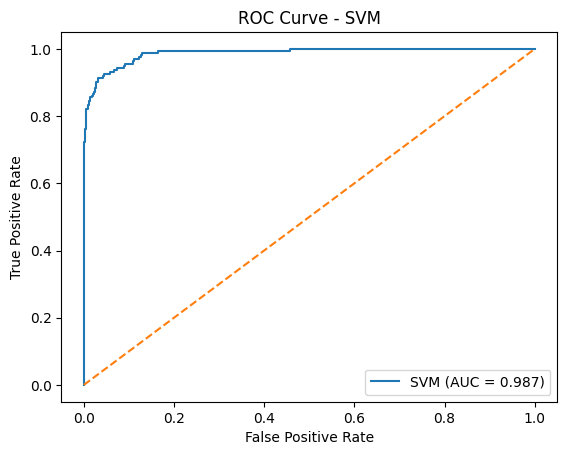

In [35]:
# Confusion Matrix
cm = confusion_matrix(y_test, svm_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Real Job", "Fake Job"])
disp.plot(values_format="d")
plt.title("Confusion Matrix - SVM")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, svm_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"SVM (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()
plt.show()

# XG Boost

In [36]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train_final, y_train)
joblib.dump(xgb_model, ARTIFACTS/"model_xgb_full.joblib")


['artifacts\\model_xgb_full.joblib']

In [37]:
xgb_pred = xgb_model.predict(X_test_final)
xgb_proba = xgb_model.predict_proba(X_test_final)[:,1]

print("XGBoost Report")
print(classification_report(y_test, xgb_pred))
print("ROC AUC:", roc_auc_score(y_test, xgb_proba))


XGBoost Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3403
           1       0.81      0.84      0.82       173

    accuracy                           0.98      3576
   macro avg       0.90      0.91      0.91      3576
weighted avg       0.98      0.98      0.98      3576

ROC AUC: 0.9897591210747402


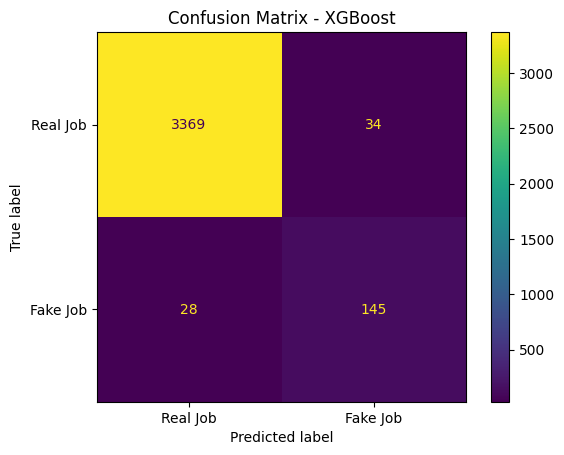

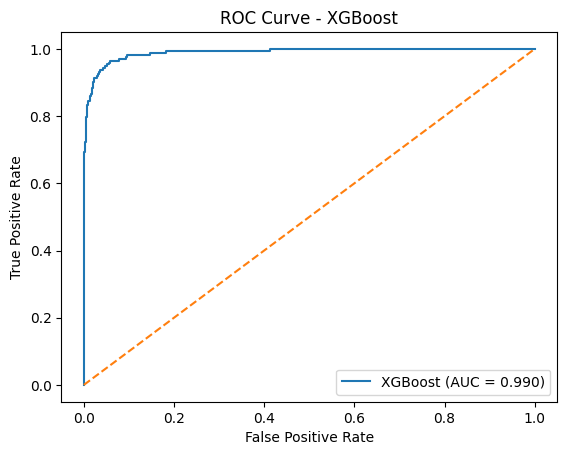

In [38]:
# Confusion Matrix
cm = confusion_matrix(y_test, xgb_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Real Job", "Fake Job"])
disp.plot(values_format="d")
plt.title("Confusion Matrix - XGBoost")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, xgb_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()

# LightGBM

In [39]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    class_weight="balanced",
    min_child_samples=20,   # prevents overfitting
    subsample=0.8,          # improves generalization
    colsample_bytree=0.8,   # good for sparse TF-IDF
    random_state=42,
    n_jobs=-1
)

lgb_model.fit(X_train_final, y_train)

joblib.dump(lgb_model, ARTIFACTS / "model_lightgbm.joblib")
print("LightGBM model saved successfully")

[LightGBM] [Info] Number of positive: 693, number of negative: 13611
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.398066 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 500173
[LightGBM] [Info] Number of data points in the train set: 14304, number of used features: 4986
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
LightGBM model saved successfully


In [40]:

lgb_pred = lgb_model.predict(X_test_final)
lgb_proba = lgb_model.predict_proba(X_test_final)[:, 1]

print("LightGBM Classification Report")
print(classification_report(y_test, lgb_pred))
print("ROC AUC:", roc_auc_score(y_test, lgb_proba))

LightGBM Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3403
           1       0.96      0.82      0.88       173

    accuracy                           0.99      3576
   macro avg       0.97      0.91      0.94      3576
weighted avg       0.99      0.99      0.99      3576

ROC AUC: 0.9898219693945667


c:\Btech\SEM4\FakeJobDeploy\job\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Btech\SEM4\FakeJobDeploy\job\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


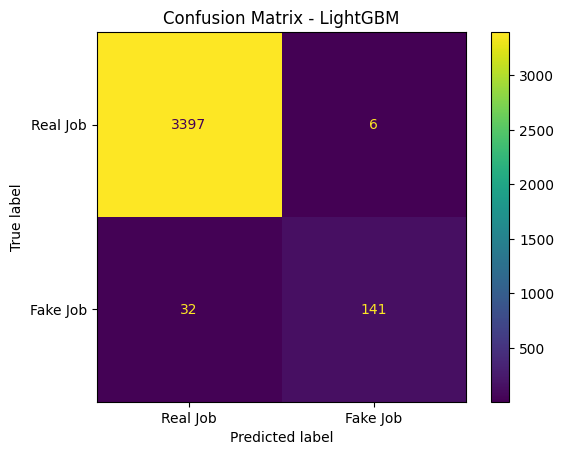

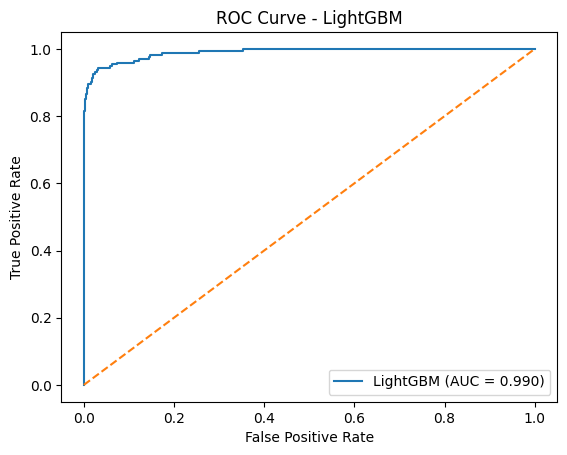

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, lgb_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Real Job", "Fake Job"]
)

disp.plot(values_format="d")
plt.title("Confusion Matrix - LightGBM")
plt.show()


fpr, tpr, _ = roc_curve(y_test, lgb_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"LightGBM (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LightGBM")
plt.legend(loc="lower right")
plt.show()

##  stacking classifier (Final model)

In [42]:
estimators = [
    ("rf", rf),             
    ("svm", svc_cal),       
    ("xgb", xgb_model),      
    ("lgbm", lgb_model)      
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(
        max_iter=3000,
        class_weight="balanced"
    ),
    n_jobs=-1
)

stack.fit(X_train_final, y_train)

joblib.dump(stack, ARTIFACTS / "final_model.joblib")

print("Final stacking ensemble saved successfully")

Final stacking ensemble saved successfully


In [43]:
stack_pred = stack.predict(X_test_final)
stack_proba = stack.predict_proba(X_test_final)[:, 1]

print("Stacking Classifier Report")
print(classification_report(y_test, stack_pred))
print("ROC AUC:", roc_auc_score(y_test, stack_proba))


c:\Btech\SEM4\FakeJobDeploy\job\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Stacking Classifier Report
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      3403
           1       0.60      0.92      0.73       173

    accuracy                           0.97      3576
   macro avg       0.80      0.94      0.85      3576
weighted avg       0.98      0.97      0.97      3576

ROC AUC: 0.9938595492926168


c:\Btech\SEM4\FakeJobDeploy\job\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


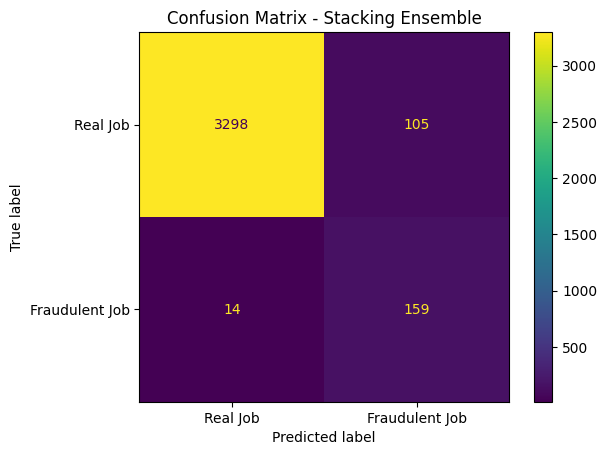

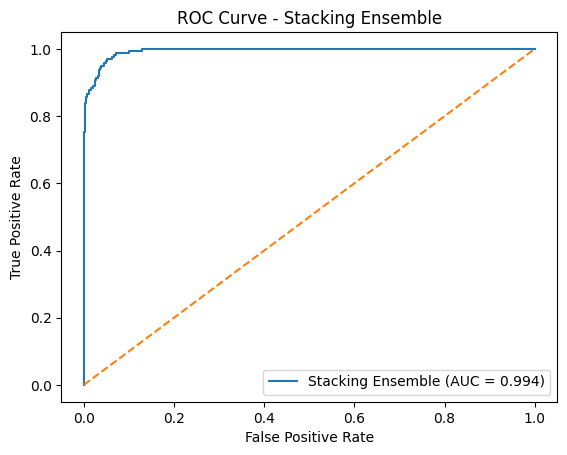

In [44]:
cm = confusion_matrix(y_test, stack_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Real Job", "Fraudulent Job"]
)

disp.plot(values_format="d")
plt.title("Confusion Matrix - Stacking Ensemble")
plt.show()


fpr, tpr, _ = roc_curve(y_test, stack_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"Stacking Ensemble (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Stacking Ensemble")
plt.legend(loc="lower right")
plt.show()

c:\Btech\SEM4\FakeJobDeploy\job\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Btech\SEM4\FakeJobDeploy\job\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


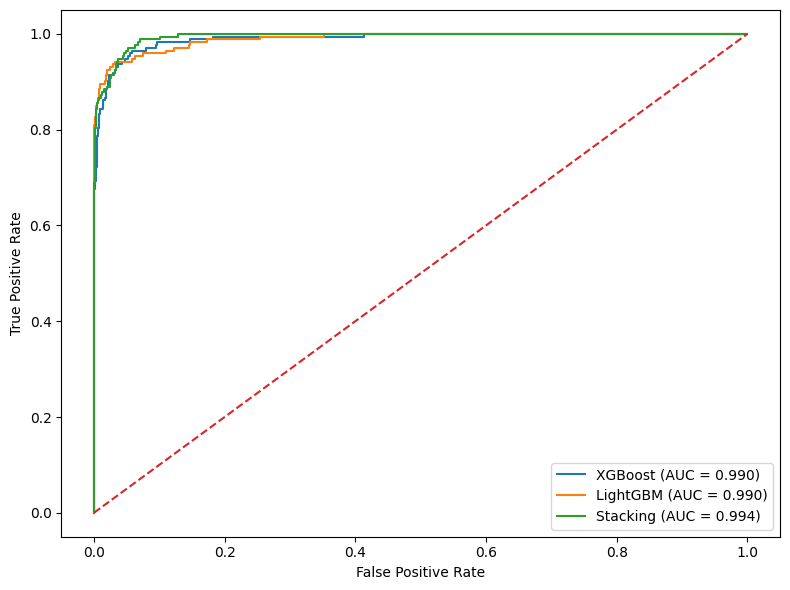

In [46]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

models = {
    "XGBoost": xgb_model,
    "LightGBM": lgb_model,
    "Stacking": stack
}

plt.figure(figsize=(8,6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test_final)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig("roc_combined.png")
plt.show()

c:\Btech\SEM4\FakeJobDeploy\job\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Btech\SEM4\FakeJobDeploy\job\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


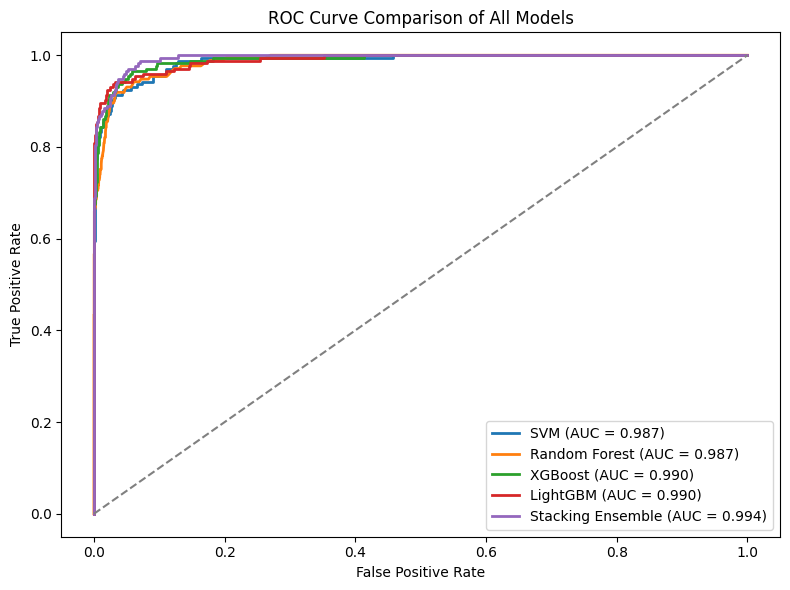

In [56]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

models = {
    "SVM": svc_cal,
    "Random Forest": rf,
    "XGBoost": xgb_model,
    "LightGBM": lgb_model,
    "Stacking Ensemble": stack
}

plt.figure(figsize=(8,6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test_final)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of All Models")
plt.legend()
plt.tight_layout()
plt.savefig("roc_all_models.png", dpi=300)
plt.show()

##Explainable AI

In [47]:


ARTIFACTS = Path("artifacts")

# Load trained XGBoost model (used for XAI)
xgb_model = joblib.load(ARTIFACTS / "model_xgb_full.joblib")

# Load TF-IDF vectorizer
tfidf = joblib.load(ARTIFACTS / "final_tfidf.joblib")

# Load meta feature names
meta_cols = joblib.load(ARTIFACTS / "meta_cols.joblib")

tfidf_features = tfidf.get_feature_names_out().tolist()
feature_names = tfidf_features + meta_cols

print("TF-IDF features:", len(tfidf_features))
print("Meta features:", len(meta_cols))
print("Total features:", len(feature_names))

TF-IDF features: 5000
Meta features: 12
Total features: 5012


In [48]:
X_train_final, X_test_final = joblib.load(ARTIFACTS / "X_all_final.joblib")

# Use a subset for SHAP (important for speed)
X_explain = X_test_final[:100]

In [49]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_explain)

# For binary classification → take fraud class (1)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

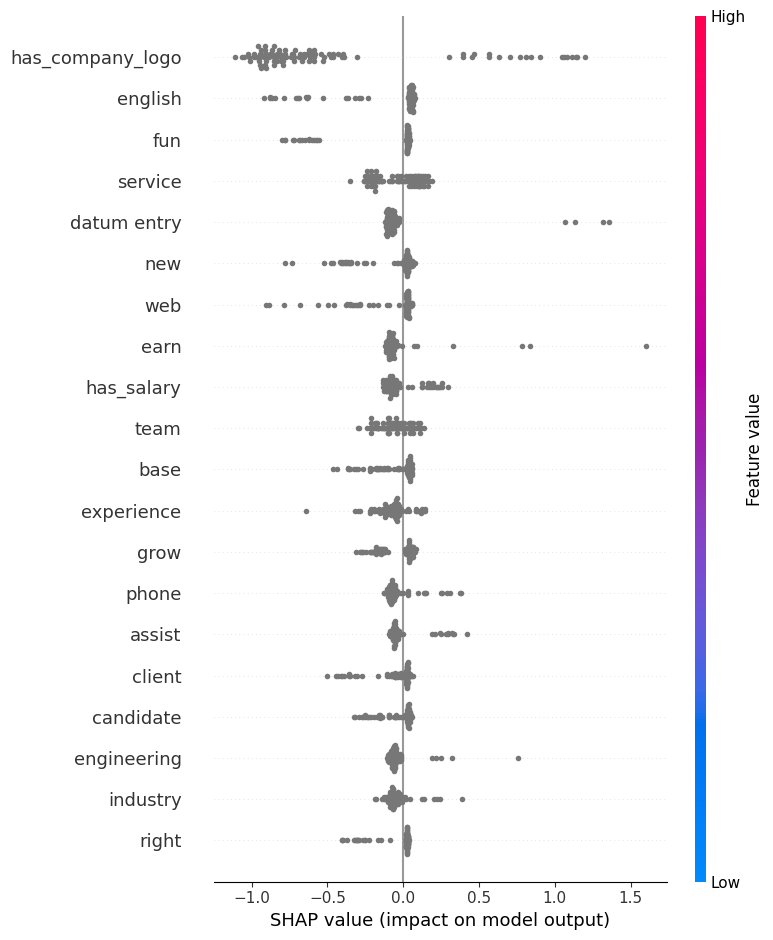

In [ ]:
shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=feature_names,
    max_display=20
)

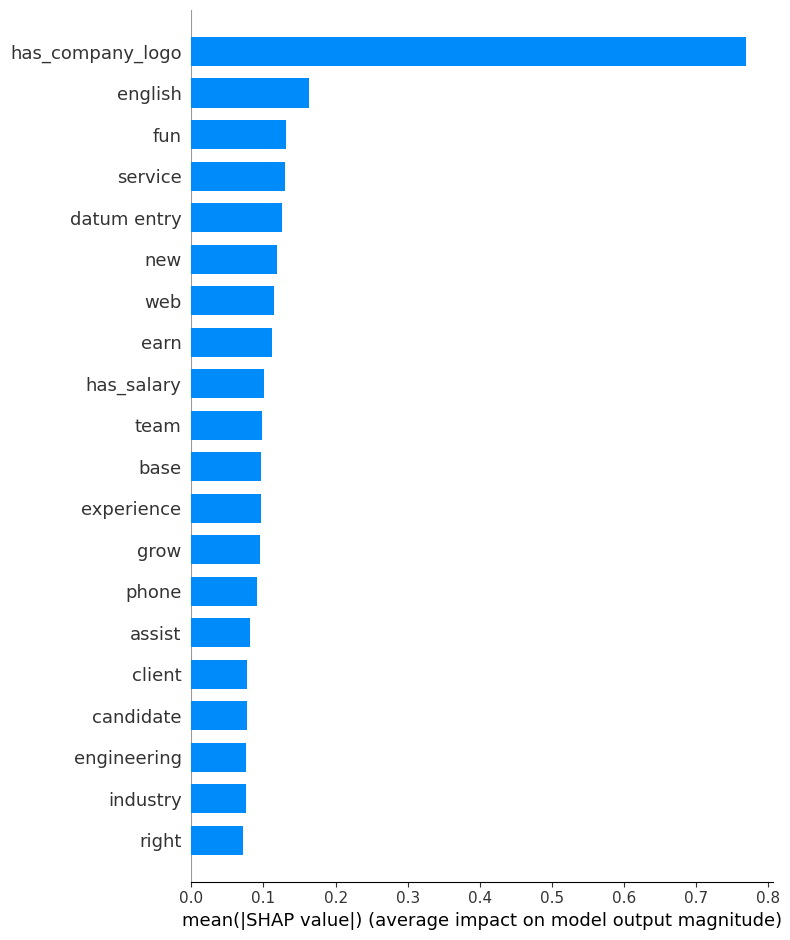

In [50]:
shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=feature_names,
    plot_type="bar",
    max_display=20
)

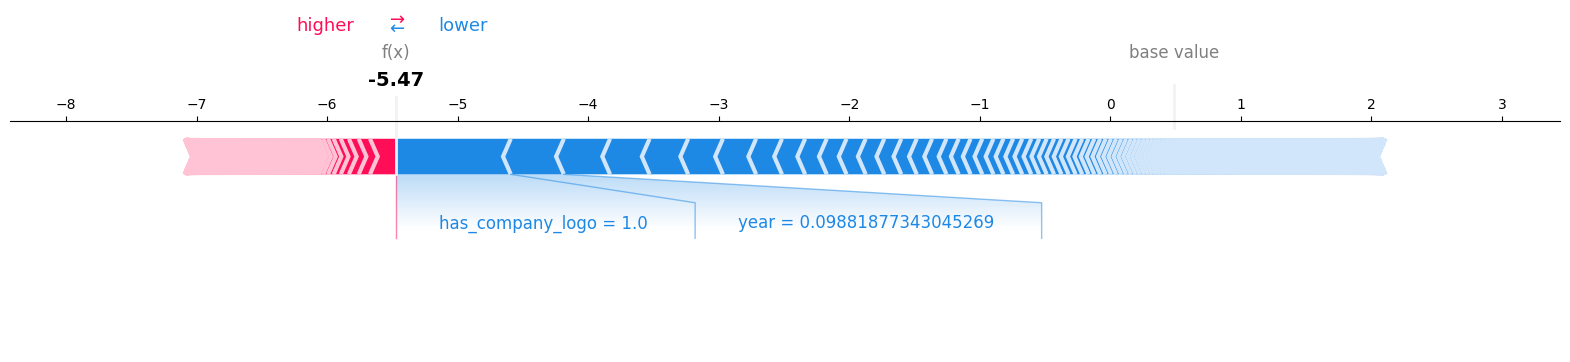

In [51]:
idx = 0  # example index

shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_explain[idx].toarray(),
    feature_names=feature_names,
    matplotlib=True
)

In [52]:
y_pred = xgb_model.predict(X_test_final)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# False Negatives: fraud predicted as real
fn_idx = np.where((y_test.values == 1) & (y_pred == 0))[0]
fp_idx = np.where((y_test.values == 0) & (y_pred == 1))[0]

print("False Negatives:", len(fn_idx))
print("False Positives:", len(fp_idx))

Confusion Matrix:
 [[3369   34]
 [  28  145]]
False Negatives: 28
False Positives: 34


In [ ]:
#Pick a false negative index
i = fn_idx[0] 
# Compute SHAP ONLY for this sample 
shap_fn = explainer.shap_values(X_test_final[i])
#  Binary classification → take fraud class 
if isinstance(shap_fn, list): 
    shap_fn = shap_fn[1]
# Force plot
shap.force_plot( 
                explainer.expected_value, 
                shap_fn, 
                X_test_final[i].toarray(), 
                feature_names=feature_names,
                matplotlib=True
                )

In [54]:
mean_shap = np.abs(shap_values).mean(axis=0)

shap_df = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_shap
}).sort_values(by="mean_abs_shap", ascending=False)

shap_df.head(20)

,feature,mean_abs_shap
5010,has_company_logo,0.768632
1488,english,0.163194
1902,fun,0.131058
3973,service,0.130444
1092,datum entry,0.126318
2930,new,0.119315
4805,web,0.115165
1370,earn,0.112425
5006,has_salary,0.101408
4396,team,0.097411


In [55]:
shap_df.to_csv(
    ARTIFACTS / "shap_global_importance.csv",
    index=False
)